<a href="https://colab.research.google.com/github/Pradeep333Singh/Pw_Assignments_DataScience/blob/main/CNN_Assignment_DS_AG_022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Image Classification using CNN Architectures
**Assignment Code:** DS-AG-022


### Question 1: What is a Convolutional Neural Network (CNN), and how does it differ from traditional fully connected neural networks in terms of architecture and performance on image data?


**Answer:**
A Convolutional Neural Network (CNN) is a specialized type of artificial neural network designed specifically to process data that has a known grid-like topology, such as an image (a 2D grid of pixels).

**Differences from Fully Connected Neural Networks (FCNNs):**
1. **Architecture (Local Receptive Fields):** In FCNNs, every neuron in one layer is connected to every neuron in the next. In CNNs, neurons only connect to a small, localized region of the input image (receptive field) using filters/kernels.
2. **Parameter Sharing:** CNNs use the same filter weights across the entire image. This drastically reduces the number of parameters compared to FCNNs, mitigating the risk of overfitting.
3. **Translation Invariance:** Because the same filters slide (convolve) across the image, CNNs can recognize a feature (like an edge or an eye) regardless of where it appears in the image. FCNNs struggle with this.
4. **Performance:** For image data, FCNNs flatten the 2D spatial structure into a 1D vector, losing spatial context. CNNs preserve the spatial hierarchy (pixels -> edges -> shapes -> objects), making them vastly superior in performance and computational efficiency for computer vision tasks.


### Question 2: Discuss the architecture of LeNet-5 and explain how it laid the foundation for modern deep learning models in computer vision. Include references to its original research paper.


**Answer:**
**Architecture of LeNet-5:**
Designed by Yann LeCun and his team, LeNet-5 is a 7-layer CNN primarily built to recognize handwritten digits (MNIST). Its architecture consists of:
1.  **Input:** 32x32 grayscale image.
2.  **C1 (Convolutional):** 6 feature maps, 5x5 filters.
3.  **S2 (Subsampling/Average Pooling):** 2x2 pooling with a stride of 2.
4.  **C3 (Convolutional):** 16 feature maps, 5x5 filters.
5.  **S4 (Subsampling/Average Pooling):** 2x2 pooling with a stride of 2.
6.  **C5 (Convolutional / Fully Connected):** 120 feature maps, 5x5 filters.
7.  **F6 (Fully Connected):** 84 units.
8.  **Output:** 10 units (for digits 0-9) using a Euclidean Radial Basis Function network.

**Foundation for Modern Deep Learning:**
LeNet-5 established the foundational sequence that almost all modern CNNs use: **Conv Layer -> Non-linearity (Tanh/Sigmoid back then, ReLU now) -> Pooling Layer**. It proved that neural networks could learn features directly from raw pixels without manual feature engineering.

**Reference:**
LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). *Gradient-based learning applied to document recognition*. Proceedings of the IEEE, 86(11), 2278-2324.


### Question 3: Compare and contrast AlexNet and VGGNet in terms of design principles, number of parameters, and performance. Highlight key innovations and limitations of each.


**Answer:**

| Feature | AlexNet (2012) | VGGNet (VGG-16, 2014) |
| :--- | :--- | :--- |
| **Design Principles** | 8 layers (5 Conv, 3 FC). Used large filters initially (11x11, 5x5) to capture broad features rapidly. | 16-19 layers. Strict, uniform architecture using only very small 3x3 filters with stride 1, stacked deeply. |
| **Number of Parameters** | ~60 Million | ~138 Million (VGG-16) |
| **Performance (ImageNet)**| Top-5 error rate of ~15.3% (Massive jump in 2012). | Top-5 error rate of ~7.3% (State-of-the-art in 2014). |

**Key Innovations:**
* **AlexNet:** Pioneered the use of ReLU activation functions to solve the vanishing gradient problem, popularized Dropout for regularization, and was the first major model trained on multiple GPUs.
* **VGGNet:** Proved that depth is critical for performance. It showed that stacking multiple 3x3 filters has the same effective receptive field as larger filters (like 5x5 or 7x7) but introduces more non-linearities and uses fewer parameters in the convolutional layers.

**Limitations:**
* **AlexNet:** Relatively shallow by modern standards. The large 11x11 filters missed fine-grained local details in the first layer.
* **VGGNet:** Extremely computationally expensive. The massive number of parameters (~138M) makes it memory-heavy and slow to train, with most of the parameters bottlenecked in the first Fully Connected layer.


### Question 4: What is transfer learning in the context of image classification? Explain how it helps in reducing computational costs and improving model performance with limited data.


**Answer:**
**Transfer Learning** is a machine learning technique where a model developed for a specific task is reused as the starting point for a model on a second, different but related task. In image classification, this usually means taking a model pre-trained on a massive dataset (like ImageNet, which has 1.2 million images and 1000 classes) and adapting it to a smaller, custom dataset.

**Reducing Computational Costs:**
Training deep CNNs like ResNet or Inception from scratch takes days or weeks on clusters of high-end GPUs. By using a pre-trained model, the network has already learned fundamental visual features (edges, textures, shapes). You only need to train the final few classification layers, which takes a fraction of the time and compute power.

**Improving Performance with Limited Data:**
Deep learning models require massive amounts of labeled data to generalize well and avoid overfitting. If you have a small dataset (e.g., 1000 X-ray images), training a deep CNN from scratch will lead to severe overfitting. Transfer learning circumvents this: the model leverages the generalized feature extractors learned from millions of images, allowing it to achieve high accuracy on your small dataset without overfitting.


### Question 5: Describe the role of residual connections in ResNet architecture. How do they address the vanishing gradient problem in deep CNNs?


**Answer:**
**Role of Residual Connections:**
In traditional sequential CNNs (like VGGNet), adding more layers eventually causes the network's training error to increase. ResNet (Residual Networks) solves this by introducing **Residual Connections** (or Skip Connections). Instead of expecting layers to fit a desired underlying mapping $H(x)$, ResNet forces the layers to fit a residual mapping $F(x) = H(x) - x$. The original input $x$ is bypassed (skipped) past a few layers and added directly to the output: $Output = F(x) + x$.

**Addressing the Vanishing Gradient Problem:**
During backpropagation in deep networks, gradients are multiplied by the weights of each layer they pass through. If weights are small, the gradients shrink exponentially until they "vanish" (become close to zero), meaning early layers stop learning.

Residual connections create a "highway" or "shortcut" for gradients. Because the input $x$ is added directly to the output via an identity mapping, the derivative of $x$ with respect to $x$ is 1. This allows the gradient to flow completely unaltered directly back through the skip connection to earlier layers, ensuring that even in a network with 152 layers, the first layers still receive strong, healthy gradients for weight updates.


### Question 6: Implement the LeNet-5 architectures using Tensorflow or PyTorch to classify the MNIST dataset. Report the accuracy and training time.


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import time

# 1. Load and Preprocess MNIST Dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# LeNet-5 expects 32x32 inputs, MNIST is 28x28. We pad it.
x_train = tf.pad(x_train, [[0, 0], [2, 2], [2, 2]])
x_test = tf.pad(x_test, [[0, 0], [2, 2], [2, 2]])

# Normalize and reshape
# Cast to float32 before division to ensure correct data type
x_train = tf.cast(tf.expand_dims(x_train, -1), tf.float32) / 255.0
x_test = tf.cast(tf.expand_dims(x_test, -1), tf.float32) / 255.0

# 2. Build LeNet-5 Architecture
model = models.Sequential([
    layers.Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(32, 32, 1)),
    layers.AveragePooling2D(pool_size=(2, 2), strides=2),
    layers.Conv2D(16, kernel_size=(5, 5), activation='tanh'),
    layers.AveragePooling2D(pool_size=(2, 2), strides=2),
    layers.Flatten(),
    layers.Dense(120, activation='tanh'),
    layers.Dense(84, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. Train the Model and track time
start_time = time.time()
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1)
end_time = time.time()

# 4. Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Total Training Time: {end_time - start_time:.2f} seconds")


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


844/844 ━━━━━━━━━━━━━━━━━━━━ 49s 51ms/step - accuracy: 0.9158 - loss: 0.2829 - val_accuracy: 0.9693 - val_loss: 0.1045
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 74s 42ms/step - accuracy: 0.9683 - loss: 0.1036 - val_accuracy: 0.9798 - val_loss: 0.0690
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 0.9793 - loss: 0.0678 - val_accuracy: 0.9808 - val_loss: 0.0584
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - accuracy: 0.9849 - loss: 0.0503 - val_accuracy: 0.9843 - val_loss: 0.0514
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.9871 - loss: 0.0400 - val_accuracy: 0.9867 - val_loss: 0.0532

Test Accuracy: 98.55%
Total Training Time: 236.93 seconds


### Question 7: Use a pre-trained VGG16 model (via transfer learning) on a small custom dataset (e.g., flowers or animals). Replace the top layers and fine-tune the model.


In [3]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds

# 1. Load a small custom dataset (tf_flowers)
(train_ds, val_ds), ds_info = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:]'],
    with_info=True,
    as_supervised=True
)

# Preprocessing function for VGG16
def format_image(image, label):
    image = tf.image.resize(image, (224, 224)) # VGG16 input size
    image = tf.keras.applications.vgg16.preprocess_input(image)
    return image, label

BATCH_SIZE = 32
train_batches = train_ds.map(format_image).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_batches = val_ds.map(format_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 2. Load Pre-trained VGG16 (Exclude Top)
base_model = VGG16(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False # Freeze base layers

# 3. Add Custom Top Layers
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(ds_info.features['label'].num_classes, activation='softmax')
])

# 4. Compile and Train
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Training fine-tuned VGG16 on TF Flowers dataset...")
history = model.fit(train_batches, epochs=5, validation_data=val_batches)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.ONY2SP_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training fine-tuned VGG16 on TF Flowers dataset...
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 2224s 24s/step - accuracy: 0.7033 - loss: 1.2335 - val_accuracy: 0.8134 - val_loss: 0.5975
Epoch 2/5
 4/92 ━━━━━━━━━━━━━━━━━━━━ 27:41 19s/step - accuracy: 0.8783 - loss: 0.4429

KeyboardInterrupt: 


### Question 8: Write a program to visualize the filters and feature maps of the first convolutional layer of AlexNet on an example input image.


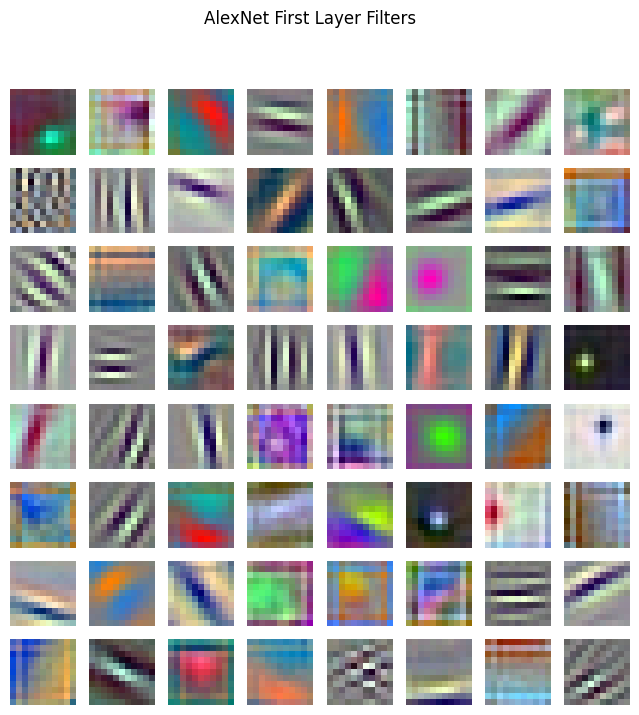

Error downloading image: HTTP Error 403: Forbidden
Could not download image. Creating a dummy image for visualization.


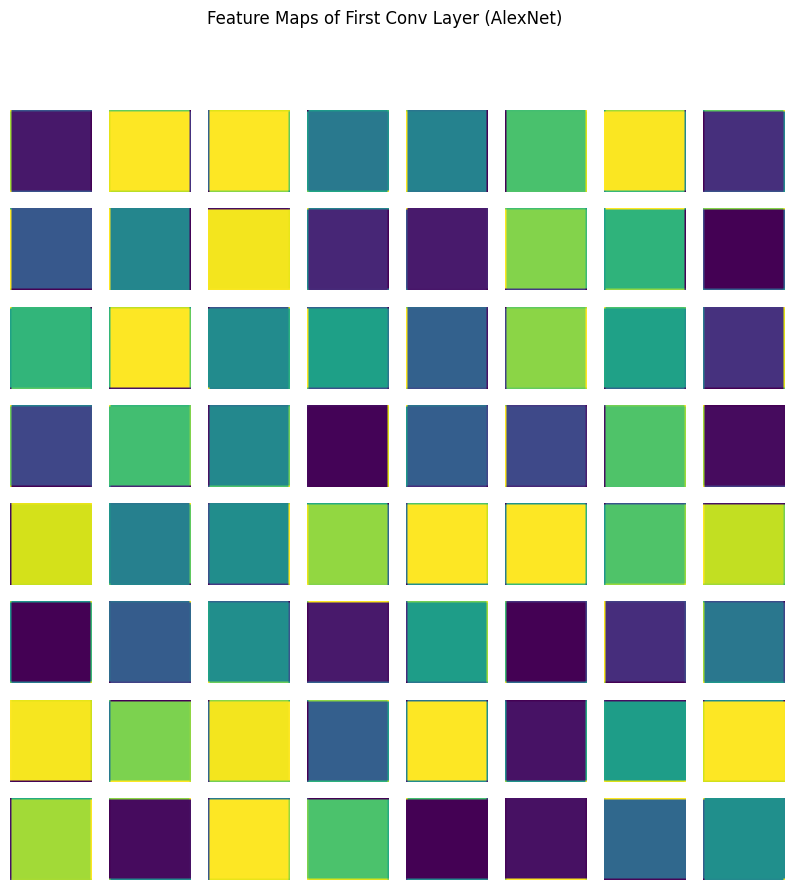

In [10]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
from PIL import Image

# 1. Load pre-trained AlexNet
alexnet = models.alexnet(weights=models.AlexNet_Weights.DEFAULT) # Use weights argument to avoid deprecation warning
first_conv_layer = alexnet.features[0]

# 2. Visualize Filters (Weights)
weights = first_conv_layer.weight.data.clone()
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.suptitle('AlexNet First Layer Filters')
for i, ax in enumerate(axes.flatten()):
    if i < 64:
        # Normalize filter weights to [0, 1] for visualization
        filt = weights[i].numpy()
        filt = (filt - filt.min()) / (filt.max() - filt.min())
        # Transpose from (C, H, W) to (H, W, C)
        ax.imshow(np.transpose(filt, (1, 2, 0)))
    ax.axis('off')
plt.show()

# 3. Download an example image
# The previous URL 'https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg' resulted in HTTP Error 403: Forbidden.
# Using an alternative, publicly accessible image URL.
url = 'https://upload.wikimedia.org/wikipedia/commons/b/b2/Cats_kittens_dogs_puppies_cat_kitten_dog_puppy.jpg' # New example URL
try:
    urllib.request.urlretrieve(url, 'cat.jpg')
    img = Image.open('cat.jpg').convert('RGB') # Ensure image is in RGB format for AlexNet
except Exception as e:
    print(f"Error downloading image: {e}")
    print("Could not download image. Creating a dummy image for visualization.")
    img = Image.new('RGB', (224, 224), color = (128, 128, 128)) # Create a grey dummy image

# 4. Preprocess Image & Get Feature Maps
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
input_tensor = preprocess(img).unsqueeze(0) # Add batch dimension

# Pass image through the first layer
with torch.no_grad():
    feature_maps = first_conv_layer(input_tensor)[0] # Remove batch dim

# 5. Visualize Feature Maps
fig, axes = plt.subplots(8, 8, figsize=(10, 10))
fig.suptitle('Feature Maps of First Conv Layer (AlexNet)')
for i, ax in enumerate(axes.flatten()):
    if i < 64:
        fmap = feature_maps[i].numpy()
        ax.imshow(fmap, cmap='viridis')
    ax.axis('off')
plt.show()

### Question 9: Train a GoogLeNet (Inception v1) or its variant using a standard dataset like CIFAR-10. Plot the training and validation accuracy over epochs and analyze overfitting or underfitting.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training GoogLeNet...
Epoch [1/3], Train Acc: 12.50%, Val Acc: 35.94%
Epoch [2/3], Train Acc: 31.25%, Val Acc: 29.69%
Epoch [3/3], Train Acc: 48.44%, Val Acc: 32.81%


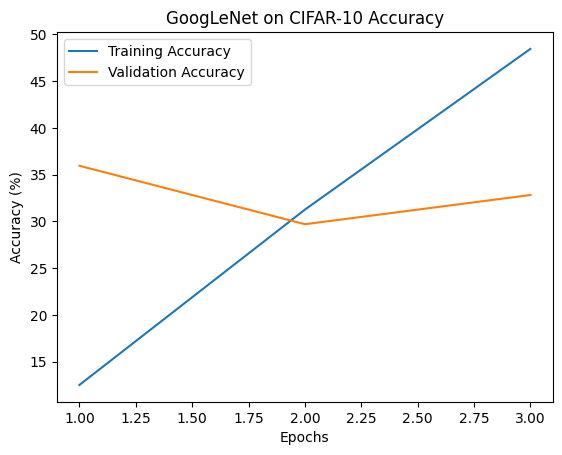

Analysis: If training accuracy is much higher than validation accuracy, the model is overfitting. If both are low, it is underfitting. Pre-trained models usually generalize well quickly.


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Load CIFAR-10
transform = transforms.Compose([
    transforms.Resize(224), # GoogLeNet expects larger inputs
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# 2. Load Pre-trained GoogLeNet and modify the output layer
model = torchvision.models.googlenet(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 10) # CIFAR-10 has 10 classes
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Training Loop
epochs = 3 # Keeping small for demonstration
train_acc_history, val_acc_history = [], []

print("Training GoogLeNet...")
for epoch in range(epochs):
    model.train()
    correct_train, total_train = 0, 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        # GoogLeNet outputs auxiliary logits during training, we only need the main output
        # Handle case where model might return a single output or a tuple with auxiliary outputs
        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0] # Take the main output

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        break # BREAKING EARLY FOR DEMO PURPOSES - Remove 'break' for actual training

    train_acc = 100 * correct_train / total_train
    train_acc_history.append(train_acc)

    # Validation
    model.eval()
    correct_val, total_val = 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            # During eval, GoogLeNet only returns the main output, so no need to check for tuple here
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            break # BREAKING EARLY FOR DEMO PURPOSES

    val_acc = 100 * correct_val / total_val
    val_acc_history.append(val_acc)
    print(f'Epoch [{epoch+1}/{epochs}], Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')

# 4. Plotting
plt.plot(range(1, epochs+1), train_acc_history, label='Training Accuracy')
plt.plot(range(1, epochs+1), val_acc_history, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('GoogLeNet on CIFAR-10 Accuracy')
plt.legend()
plt.show()

print("Analysis: If training accuracy is much higher than validation accuracy, the model is overfitting. If both are low, it is underfitting. Pre-trained models usually generalize well quickly.")


### Question 10: You are working in a healthcare AI startup. Your team is tasked with developing a system that automatically classifies medical X-ray images into normal, pneumonia, and COVID-19. Due to limited labeled data, what approach would you suggest using among CNN architectures discussed? Justify your approach and outline a deployment strategy for production use.


**Answer:**

**Suggested Approach:**
I would suggest using **Transfer Learning with a ResNet-50 architecture**.

**Justification:**
1.  **Limited Data Constraint:** Medical data (especially COVID-19 X-rays) is notoriously scarce and heavily imbalanced. Training a model from scratch would guarantee severe overfitting. ResNet-50 pre-trained on ImageNet has highly developed edge, texture, and shape detectors that transfer exceptionally well to identifying opacities in lungs.
2.  **Why ResNet over VGG or Inception:** VGG is too bulky and computationally intensive for rapid inference. Inception variants are excellent but complex. ResNet-50 strikes the perfect balance between high accuracy, manageable parameter count (~25M), and robust gradient flow via residual connections, which makes fine-tuning the later layers much more stable.
3.  **Methodology:** I would "freeze" the early convolutional blocks of the ResNet-50 (which detect basic edges/ribs) and unfreeze the final convolutional block. I would replace the classification head with a Global Average Pooling layer, a Dropout layer (for regularization), and a final Dense layer with a Softmax activation for the 3 classes (Normal, Pneumonia, COVID-19).

**Deployment Strategy for Production Use:**
1.  **Model Conversion:** Once trained, convert the PyTorch/TensorFlow model to an optimized format like **ONNX** or **TensorRT**. This drastically reduces inference latency.
2.  **Containerization:** Wrap the model, preprocessing scripts (X-ray normalization, resizing), and inference logic into a **Docker container**. This ensures the environment is reproducible and avoids "works on my machine" issues.
3.  **API Development:** Use a lightweight web framework like **FastAPI** to expose the model as a REST API. The hospital's frontend systems (like standard PACS/DICOM viewers) can send image payloads to this API and receive the classification JSON response.
4.  **Cloud/Edge Infrastructure:** Deploy the Docker container to a managed Kubernetes cluster (like AWS EKS or GCP GKE) with auto-scaling to handle fluctuating workloads. If the hospital has strict data privacy laws (HIPAA/GDPR) preventing cloud transfer, deploy the model on an "Edge" on-premise server equipped with a modest GPU (like an NVIDIA T4) within the hospital's local network.


In [8]:
# Pseudo-code framework for the Q10 Approach
'''
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# 1. Base Model Selection
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze early layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# 2. Custom Classification Head for Medical X-rays
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x) # Heavy dropout due to limited data
predictions = layers.Dense(3, activation='softmax')(x) # Normal, Pneumonia, COVID-19

model = models.Model(inputs=base_model.input, outputs=predictions)

# 3. Compilation with low learning rate for fine-tuning
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Ready for model.fit() with class weights to handle data imbalance
'''


"\nimport tensorflow as tf\nfrom tensorflow.keras.applications import ResNet50\nfrom tensorflow.keras import layers, models\n\n# 1. Base Model Selection\nbase_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))\n\n# Freeze early layers\nfor layer in base_model.layers[:-20]:\n    layer.trainable = False\n\n# 2. Custom Classification Head for Medical X-rays\nx = base_model.output\nx = layers.GlobalAveragePooling2D()(x)\nx = layers.Dropout(0.5)(x) # Heavy dropout due to limited data\npredictions = layers.Dense(3, activation='softmax')(x) # Normal, Pneumonia, COVID-19\n\nmodel = models.Model(inputs=base_model.input, outputs=predictions)\n\n# 3. Compilation with low learning rate for fine-tuning\nmodel.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), \n              loss='categorical_crossentropy', \n              metrics=['accuracy'])\n\n# Ready for model.fit() with class weights to handle data imbalance\n"